In [47]:
import torch
import torch.nn as nn  # nn contains all of PyTorch building blocks for neural networks

import matplotlib.pyplot as plt


torch.__version__

'2.11.0+cu128'

In [48]:
## Data preparing and loading



In [49]:
# creating know paramters
weight = 0.7
bias = 0.3

#  create  y = a + bx

start = 0
end = 1
step = 0.02

X = torch.arange(start, end, step).unsqueeze(dim=1)
y = weight * X + bias

X[:10], y[:10]

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800]]),
 tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560],
         [0.3700],
         [0.3840],
         [0.3980],
         [0.4120],
         [0.4260]]))

In [50]:
len(X), len(y)

(50, 50)

In [51]:
## Spilting the data into train and test

train_split = int(0.8 * len(X))
train_split

40

In [52]:
X_train = X[:train_split]
X_train, len(X_train)

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800],
         [0.2000],
         [0.2200],
         [0.2400],
         [0.2600],
         [0.2800],
         [0.3000],
         [0.3200],
         [0.3400],
         [0.3600],
         [0.3800],
         [0.4000],
         [0.4200],
         [0.4400],
         [0.4600],
         [0.4800],
         [0.5000],
         [0.5200],
         [0.5400],
         [0.5600],
         [0.5800],
         [0.6000],
         [0.6200],
         [0.6400],
         [0.6600],
         [0.6800],
         [0.7000],
         [0.7200],
         [0.7400],
         [0.7600],
         [0.7800]]),
 40)

In [53]:
y_train = y[: train_split]
y_train, len(y_train)

(tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560],
         [0.3700],
         [0.3840],
         [0.3980],
         [0.4120],
         [0.4260],
         [0.4400],
         [0.4540],
         [0.4680],
         [0.4820],
         [0.4960],
         [0.5100],
         [0.5240],
         [0.5380],
         [0.5520],
         [0.5660],
         [0.5800],
         [0.5940],
         [0.6080],
         [0.6220],
         [0.6360],
         [0.6500],
         [0.6640],
         [0.6780],
         [0.6920],
         [0.7060],
         [0.7200],
         [0.7340],
         [0.7480],
         [0.7620],
         [0.7760],
         [0.7900],
         [0.8040],
         [0.8180],
         [0.8320],
         [0.8460]]),
 40)

In [54]:
X_test = X[train_split: ]
X_test, len(X_test)

(tensor([[0.8000],
         [0.8200],
         [0.8400],
         [0.8600],
         [0.8800],
         [0.9000],
         [0.9200],
         [0.9400],
         [0.9600],
         [0.9800]]),
 10)

In [55]:
y_test = y[train_split: ]
y_test, len(y_test)

(tensor([[0.8600],
         [0.8740],
         [0.8880],
         [0.9020],
         [0.9160],
         [0.9300],
         [0.9440],
         [0.9580],
         [0.9720],
         [0.9860]]),
 10)

In [56]:
def plot_predictions(train_data=X_train,
                     train_labels=y_train,
                     test_data=X_test,
                     test_labels=y_test,
                     predictions=None):

    plt.figure(figsize=(10, 7))

    # Training data
    plt.scatter(train_data, train_labels,
                c="b", s=4, label="Training data")

    # Testing data
    plt.scatter(test_data, test_labels,
                c="g", s=4, label="Testing data")

    # Predictions, if available
    if predictions is not None:
        plt.scatter(test_data, predictions,
                    c="r", s=4, label="Predictions")

    # Legend
    plt.legend(prop={"size": 14})

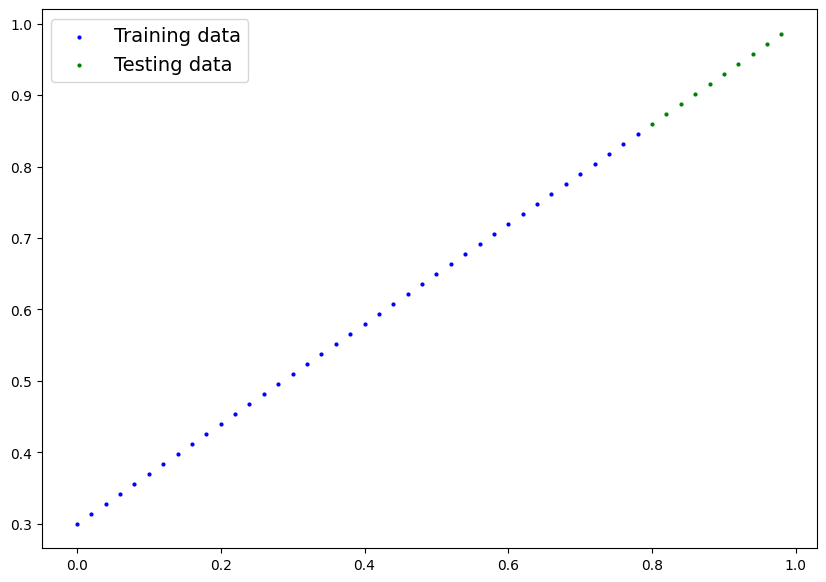

In [57]:
plot_predictions()

### Our model process:

* Start with random values weight & bias

* Look at training data and adjust the random vlaues to better represent or get closer to the ideal values the weight & bias values we used to create the data

This is done by two alogrithms

* Gradient descent
* Backpropagation

In [58]:
from numpy import require
# Build a Pytorch model
# y = a + bx
class LineatRegressionModel(nn.Module):
    def __init__(self):
      super().__init__()
      self.weights = nn.Parameter(torch.randn(1, requires_grad= True, dtype=float))
      self.bias = nn.Parameter(torch.randn(1,
                                             requires_grad= True,
                                             dtype=torch.float
                                             ))
    def forward(self, x: torch.Tensor) ->  torch.Tensor:
       # < x is the input data
      return self.weights * x  + self.bias # this is lineaer regression formula




### Checking the contents of the PyTorch Model

In [59]:
torch.randn(1)

tensor([0.2345])

In [60]:
# creating a random seed





In [61]:
# create an instance of the model
torch.manual_seed(42)
model = LineatRegressionModel()
list(model.parameters())

[Parameter containing:
 tensor([0.3367], dtype=torch.float64, requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)]

In [62]:
model.state_dict()

OrderedDict([('weights', tensor([0.3367], dtype=torch.float64)),
             ('bias', tensor([0.1288]))])

In [63]:
weight, bias

(0.7, 0.3)

### Making predictions with neural network model

In [64]:
X_test, y_test

(tensor([[0.8000],
         [0.8200],
         [0.8400],
         [0.8600],
         [0.8800],
         [0.9000],
         [0.9200],
         [0.9400],
         [0.9600],
         [0.9800]]),
 tensor([[0.8600],
         [0.8740],
         [0.8880],
         [0.9020],
         [0.9160],
         [0.9300],
         [0.9440],
         [0.9580],
         [0.9720],
         [0.9860]]))

In [65]:
with torch.inference_mode():
  y_preds = model(X_test)
y_preds

tensor([[0.3982],
        [0.4049],
        [0.4116],
        [0.4184],
        [0.4251],
        [0.4318],
        [0.4386],
        [0.4453],
        [0.4520],
        [0.4588]], dtype=torch.float64)

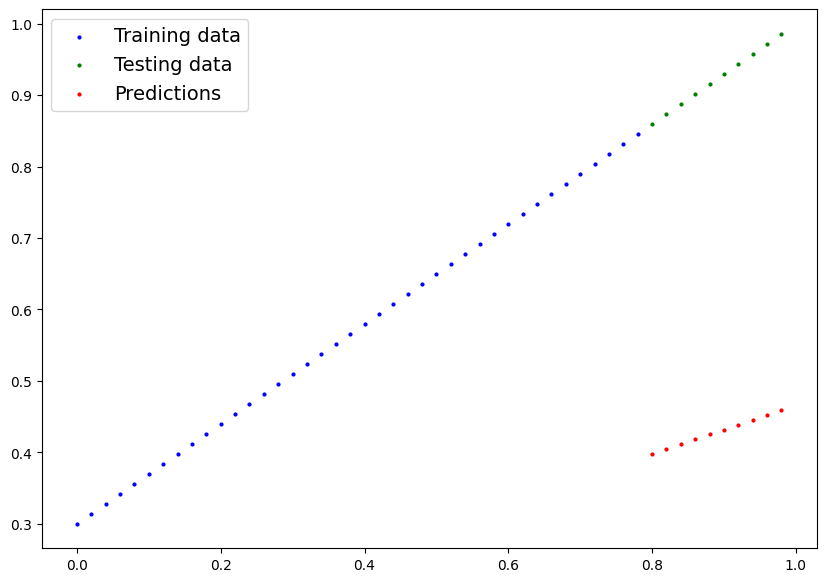

In [66]:
plot_predictions(predictions=y_preds)

In [67]:
# we can also predict with torch.no_grad()
with torch.no_grad():
  ypreds = model(X_test)

y_preds

tensor([[0.3982],
        [0.4049],
        [0.4116],
        [0.4184],
        [0.4251],
        [0.4318],
        [0.4386],
        [0.4453],
        [0.4520],
        [0.4588]], dtype=torch.float64)

### Train the model on unkown data set

In [68]:
model.parameters()

<generator object Module.parameters at 0x7833ca0451c0>

In [69]:
model.state_dict()

OrderedDict([('weights', tensor([0.3367], dtype=torch.float64)),
             ('bias', tensor([0.1288]))])

In [70]:
# Loss funtion
loss_fn = nn.L1Loss()
loss_fn

L1Loss()

In [71]:
# setting up a optimizer

In [72]:
optimizer = torch.optim.SGD(params = model.parameters(), lr = 0.01)

In [73]:

torch.manual_seed(42)

# epochs is one loop throught the data
epochs = 200
# Track different values
epoch_count = []
loss_values = []
test_loss_values = []
# train the mdeol
# loop throught the data
for epoch in range(epochs):
  model.train() #   train mode in PyTorch sets all parameters that require gradeints to optimize the gradients

  # 1. Forward pass
  y_pred = model(X_train)

  # 2. Calculate the loss
  loss  = loss_fn(y_pred, y_train)
  #print(f"Loss {loss}")
  # 3. optimizer zero grad
  optimizer.zero_grad()

  # 4. backpropagation
  loss.backward()

  # perform gradeint descent
  optimizer.step()
  # testing
  model.eval()
  with torch.inference_mode():
    # forwad the pass
    test_pred = model(X_test)
    # calculate loss
    test_loss = loss_fn(test_pred, y_test)

  if epoch % 10 == 0:
    epoch_count.append(epoch)
    loss_values.append(loss)
    test_loss_values.append(test_loss)



  print(f"Epoch: {epoch} | Loss: {loss} Test loss: {test_loss}")



  print(model.state_dict())

Epoch: 0 | Loss: 0.31288135462074396 Test loss: 0.48106517657284636
OrderedDict({'weights': tensor([0.3406], dtype=torch.float64), 'bias': tensor([0.1388])})
Epoch: 1 | Loss: 0.30136034931996125 Test loss: 0.46759417124384467
OrderedDict({'weights': tensor([0.3445], dtype=torch.float64), 'bias': tensor([0.1488])})
Epoch: 2 | Loss: 0.28983934401917866 Test loss: 0.454123165914843
OrderedDict({'weights': tensor([0.3484], dtype=torch.float64), 'bias': tensor([0.1588])})
Epoch: 3 | Loss: 0.27831833871839606 Test loss: 0.4406521605858412
OrderedDict({'weights': tensor([0.3523], dtype=torch.float64), 'bias': tensor([0.1688])})
Epoch: 4 | Loss: 0.26679733341761336 Test loss: 0.4271811552568396
OrderedDict({'weights': tensor([0.3562], dtype=torch.float64), 'bias': tensor([0.1788])})
Epoch: 5 | Loss: 0.25527632811683076 Test loss: 0.41371014992783783
OrderedDict({'weights': tensor([0.3601], dtype=torch.float64), 'bias': tensor([0.1888])})
Epoch: 6 | Loss: 0.24375532281604814 Test loss: 0.400239

In [74]:
import numpy as np

np.array(torch.tensor(epoch_count).cpu().numpy()), np.array(torch.tensor(loss_values).cpu().numpy()), test_loss_values

(array([  0,  10,  20,  30,  40,  50,  60,  70,  80,  90, 100, 110, 120,
        130, 140, 150, 160, 170, 180, 190]),
 array([0.31288135, 0.1976713 , 0.0890872 , 0.05314849, 0.04543793,
        0.04167861, 0.0381893 , 0.03476087, 0.03132382, 0.0278874 ,
        0.02445897, 0.02102024, 0.0175855 , 0.01415545, 0.01071665,
        0.0072836 , 0.00385186, 0.0089323 , 0.0089323 , 0.0089323 ]),
 [tensor(0.4811, dtype=torch.float64),
  tensor(0.3464, dtype=torch.float64),
  tensor(0.2173, dtype=torch.float64),
  tensor(0.1446, dtype=torch.float64),
  tensor(0.1136, dtype=torch.float64),
  tensor(0.0992, dtype=torch.float64),
  tensor(0.0889, dtype=torch.float64),
  tensor(0.0806, dtype=torch.float64),
  tensor(0.0723, dtype=torch.float64),
  tensor(0.0647, dtype=torch.float64),
  tensor(0.0565, dtype=torch.float64),
  tensor(0.0482, dtype=torch.float64),
  tensor(0.0406, dtype=torch.float64),
  tensor(0.0323, dtype=torch.float64),
  tensor(0.0241, dtype=torch.float64),
  tensor(0.0165, dtype=

In [75]:
# making predicitions
with torch.inference_mode():
  y_preds_new = model(X_test)


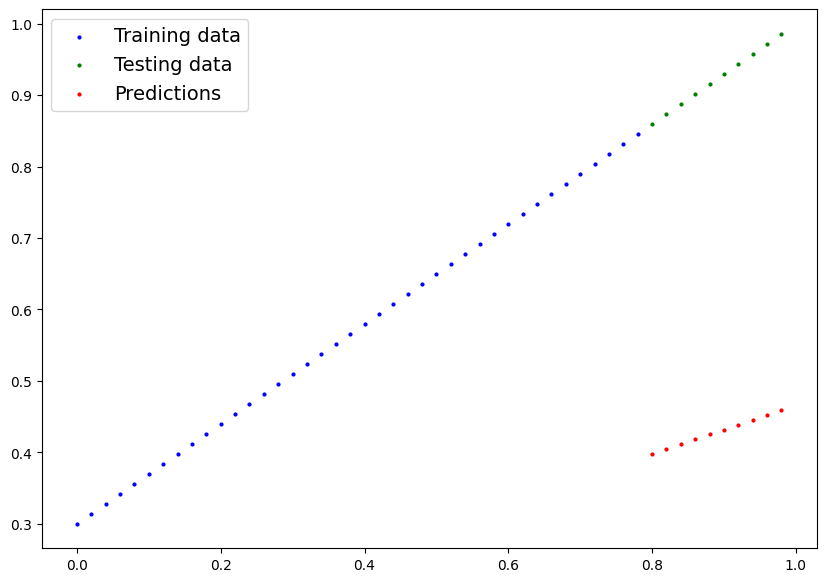

In [76]:
plot_predictions(predictions=y_preds)

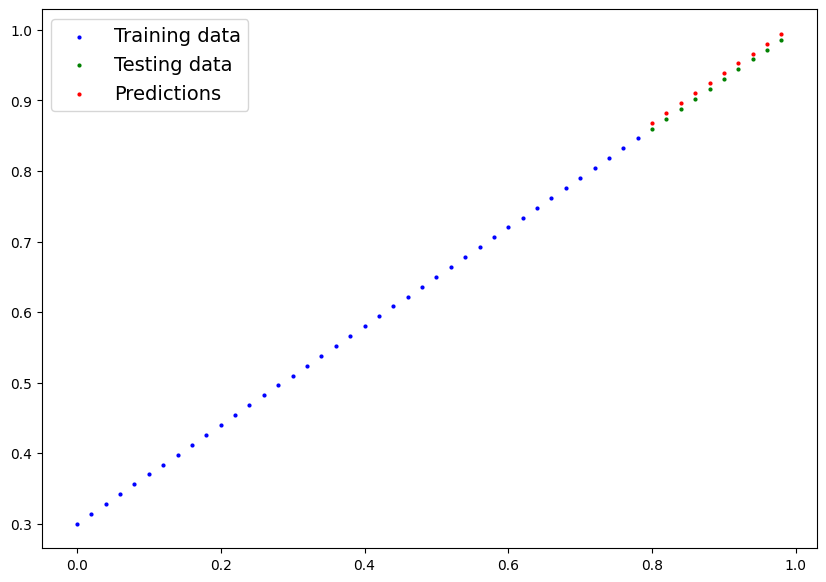

In [77]:
plot_predictions(predictions=y_preds_new)

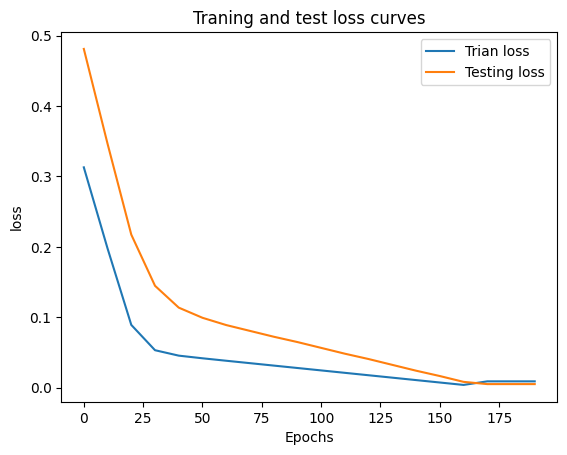

In [78]:
plt.plot(epoch_count, np.array(torch.tensor(loss_values).cpu().numpy()), label="Trian loss")
plt.plot(epoch_count, test_loss_values, label="Testing loss")

plt.title("Traning and test loss curves")
plt.xlabel("Epochs")
plt.ylabel("loss")
plt.legend()

In [79]:
#%pip install pathlib

In [80]:
## saving the pytoch model:

from  pathlib import Path
# model directory
model_path = Path("models")
model_path.mkdir(parents=True, exist_ok=True)
# model save path
model_name = "linear_regression_model.pt"

model_save_path = model_path / model_name

model_save_path

# save model sate dict
print(f"Saving to :{model_save_path}")
torch.save(obj=model.state_dict(),f=model_save_path )

Saving to :models/linear_regression_model.pt


In [81]:
!ls-l models

/bin/bash: line 1: ls-l: command not found


In [82]:
# load the model

# instantiate a new instance of our model class
loaded_model_01 = LineatRegressionModel()

# loading the save model state dict of model
loaded_model_01.load_state_dict(torch.load(f=model_save_path))

<All keys matched successfully>

In [83]:
loaded_model_01.state_dict()

OrderedDict([('weights', tensor([0.6990], dtype=torch.float64)),
             ('bias', tensor([0.3093]))])

In [84]:
# making some predcitions with our loaded model
loaded_model_01.eval()
with torch.inference_mode():
  loaded_model_preds = loaded_model_01(X_test)

loaded_model_preds

tensor([[0.8685],
        [0.8825],
        [0.8965],
        [0.9105],
        [0.9245],
        [0.9384],
        [0.9524],
        [0.9664],
        [0.9804],
        [0.9944]], dtype=torch.float64)

In [85]:
model.eval()
with torch.inference_mode():
  y_preds = model(X_test)

y_preds

tensor([[0.8685],
        [0.8825],
        [0.8965],
        [0.9105],
        [0.9245],
        [0.9384],
        [0.9524],
        [0.9664],
        [0.9804],
        [0.9944]], dtype=torch.float64)

In [86]:
# comparing loaded model preds with orignal model preds
y_preds == loaded_model_preds

tensor([[True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True]])

In [87]:
# device agnostive code: use gpu if available else use cpu

In [88]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cuda


In [89]:
# Pytorch and matplotlib
import torch
from torch import nn
import matplotlib.pyplot as plt

In [90]:
# creating some data using linear regression model using formula y = weight * X + bias

weight = 0.7
bias = 0.3

start = 0
end = 1
step = 0.02
#  creating x and Y features and labels)
X = torch.arange(start, end, step).unsqueeze(dim=1)
y = weight * X + bias
X[:10], y[:10]


(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800]]),
 tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560],
         [0.3700],
         [0.3840],
         [0.3980],
         [0.4120],
         [0.4260]]))

In [91]:
from types import TracebackType
# spliting data
train_split = int(0.8 * len(X))
X_train, y_train =  X[:train_split], y[:train_split]
X_test, y_test = X[train_split:], y[train_split:]
len(X_train), len(y_train), len(X_test), len(y_test)

(40, 40, 10, 10)

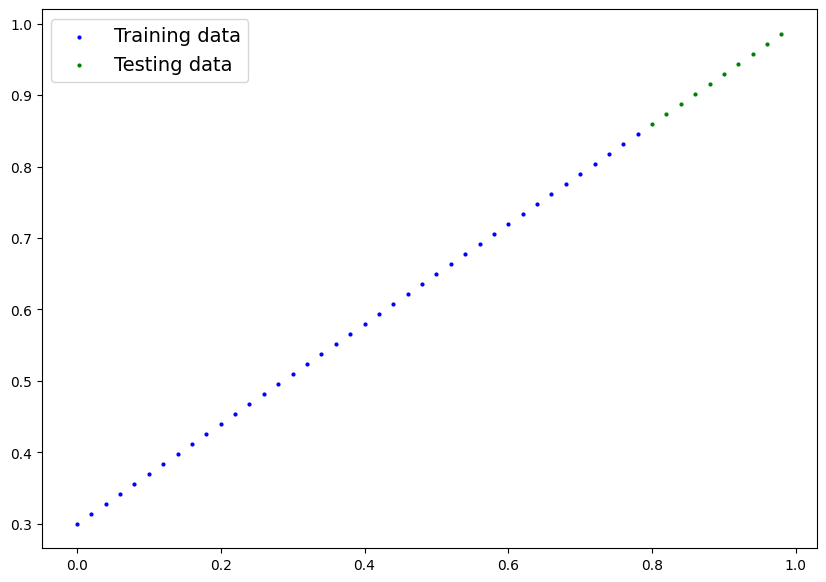

In [93]:
plot_predictions(X_train, y_train, X_test, y_test)

In [91]:
# creating a model by subclass nn.Module
class LineatRegressionModelV2(nn.Module):
  def __init__(self):
    super().__init__()
    # Linear Regression Model

    self.linear_layer = nn.Linear(in_features=1,
                                  out_features=1)


In [94]:
X_train[:1], y_train[:1]

(tensor([[0.]]), tensor([[0.3000]]))